# AS5048 encoder noise characterization — dial + motor

Characterizes the sensor noise of **both** encoders (dial and motor) from a
bench capture, and emits per-encoder coefficients for the SIL encoder model's
deterministic dither (`As5048Model::with_noise(sigma_lsb, seed)` — see
`docs/sil/backlog.md`, "Encoder sensor noise").

**Input:** `encoder_noise_raw.csv` (this directory) — `dial_raw` and
`motor_raw` telemetry over serial at the 2 ms tier, 10k samples each. The
shafts were moved between rest positions during capture, so noise is measured
**within stationary dwell segments** only; the analysis is
sample-index-based per signal, so the concatenated capture blocks (the `t`
restart) do not matter.

**Method (per signal):** rolling-median dwell segmentation -> per-segment
residuals about the segment median -> pooled sigma / MAD / histogram ->
autocorrelation (whiteness) -> quantization deconvolution -> coefficients.

Run with the repo venv kernel (`.venv` — matplotlib + ipykernel via
`requirements.txt`).

In [103]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CSV = Path("encoder_noise_raw.csv")
COUNTS_PER_REV = 16384  # AS5048: 14-bit
LSB_TO_MDEG = 360.0 / COUNTS_PER_REV * 1000.0

raw = defaultdict(list)
with open(CSV) as f:
    for row in csv.DictReader(f):
        raw[row["signalName"]].append(float(row["value"]))
signals = {name.split("/")[-1]: np.array(vals) for name, vals in sorted(raw.items())}
for name, v in signals.items():
    print(f"{name}: {len(v)} samples, range {v.min():.0f}..{v.max():.0f} counts")

dial_raw: 10000 samples, range 9143..9153 counts
motor_raw: 10000 samples, range 8932..8943 counts


## Raw captures

Rest positions appear as flat dwells; sweeps between them are shaft movement
and are excluded from the noise statistics.

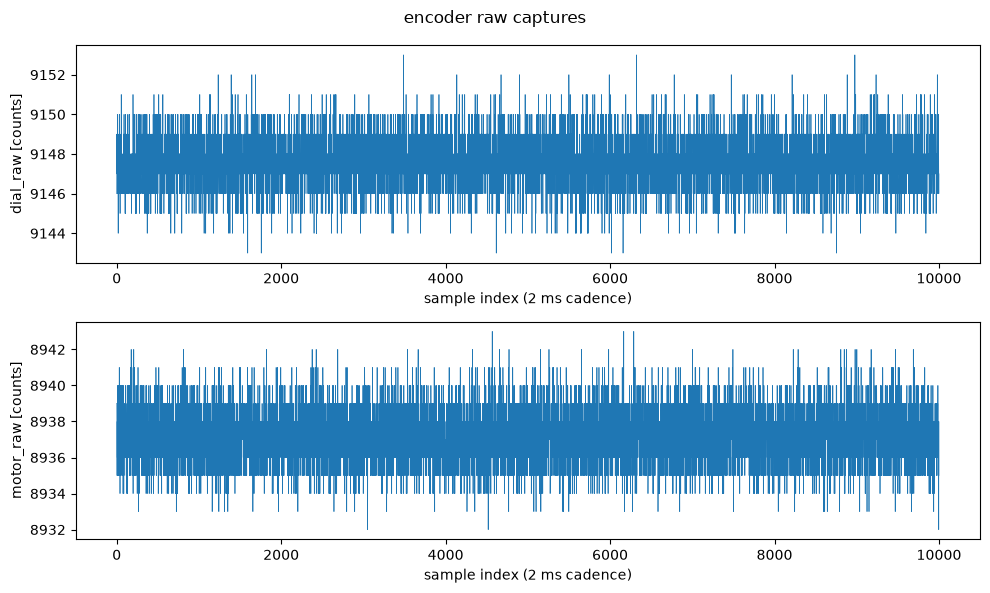

In [104]:
fig, axes = plt.subplots(len(signals), 1, figsize=(10, 3.0 * len(signals)), sharex=False)
for ax, (name, v) in zip(np.atleast_1d(axes), signals.items()):
    ax.plot(v, lw=0.5)
    ax.set_ylabel(f"{name} [counts]")
    ax.set_xlabel("sample index (2 ms cadence)")
fig.suptitle("encoder raw captures")
fig.tight_layout()

## Dwell segmentation

A sample is *dwelling* when the local rolling median (window `W`) moves less
than `TOL` counts across the window; contiguous dwell runs of at least
`MIN_LEN` samples become segments. Slow creep (a relaxing knob) fails the
tolerance and is conservatively excluded along with movement sweeps.

In [105]:
W, TOL, MIN_LEN = 15, 10.0, 200

def dwell_segments(v):
    n = len(v)
    med = np.array([np.median(v[max(0, i - W):i + W + 1]) for i in range(n)])
    dwelling = np.abs(np.gradient(med)) * W <= TOL
    segs, start = [], None
    for i, d in enumerate(dwelling):
        if d and start is None:
            start = i
        if (not d or i == n - 1) and start is not None:
            end = i if not d else i + 1
            if end - start >= MIN_LEN:
                segs.append((start, end))
            start = None
    return segs

analysis = {}
for name, v in signals.items():
    segs = dwell_segments(v)
    residuals = [v[s:e] - np.median(v[s:e]) for s, e in segs]
    r = np.concatenate(residuals)
    analysis[name] = (segs, r)
    print(f"{name}: {len(segs)} segments, {len(r)} pooled residual samples")
    print(f"{'range':>16}  {'n':>5}  {'center':>8}  {'sigma':>6}  {'span':>4}")
    for s, e in segs:
        seg = v[s:e]
        res = seg - np.median(seg)
        print(f"[{s:6d}..{e:6d})  {e - s:5d}  {np.median(seg):8.1f}  "
              f"{res.std(ddof=1):6.3f}  {seg.max() - seg.min():4.0f}")
    print()

dial_raw: 1 segments, 10000 pooled residual samples
           range      n    center   sigma  span
[     0.. 10000)  10000    9148.0   1.256    10

motor_raw: 1 segments, 10000 pooled residual samples
           range      n    center   sigma  span
[     0.. 10000)  10000    8937.0   1.544    11



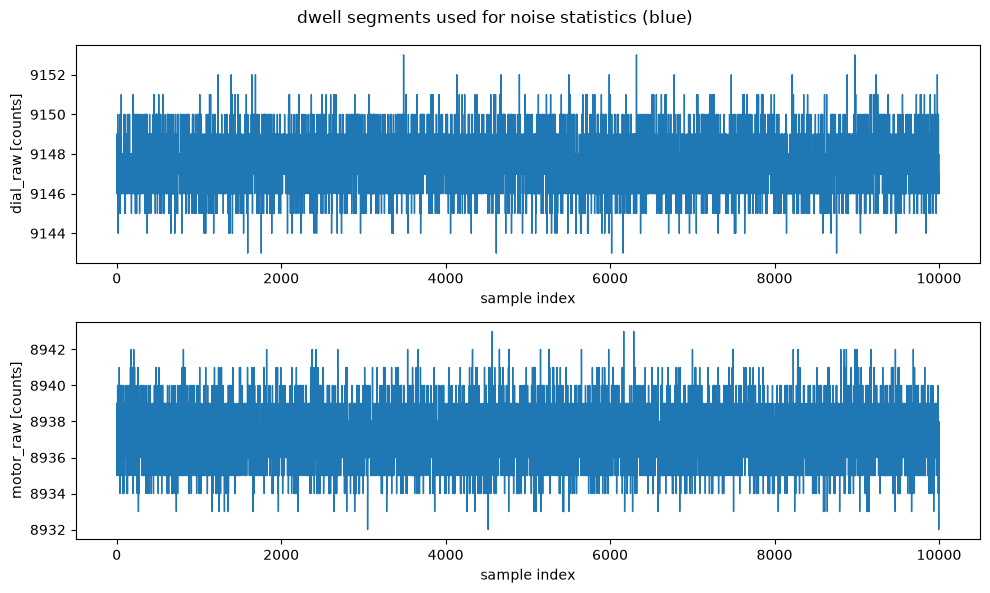

In [106]:
fig, axes = plt.subplots(len(signals), 1, figsize=(10, 3.0 * len(signals)))
for ax, (name, v) in zip(np.atleast_1d(axes), signals.items()):
    segs, _ = analysis[name]
    ax.plot(v, lw=0.4, color="0.75")
    for s, e in segs:
        ax.plot(range(s, e), v[s:e], lw=1.0, color="tab:blue")
    ax.set_ylabel(f"{name} [counts]")
    ax.set_xlabel("sample index")
fig.suptitle("dwell segments used for noise statistics (blue)")
fig.tight_layout()

## Noise distributions

dial_raw: sigma=1.256 LSB (27.6 mdeg)   MAD-sigma=1.483 LSB
motor_raw: sigma=1.544 LSB (33.9 mdeg)   MAD-sigma=1.483 LSB


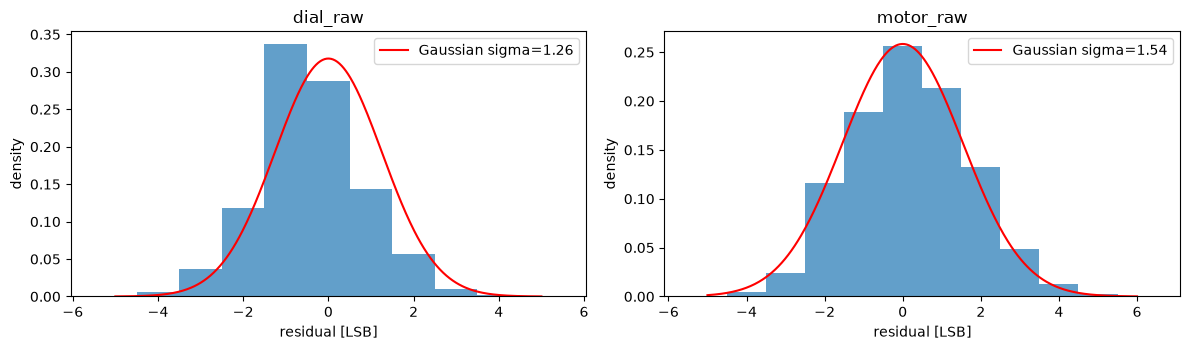

In [107]:
stats = {}
fig, axes = plt.subplots(1, len(signals), figsize=(6.0 * len(signals), 3.6))
for ax, (name, (segs, r)) in zip(np.atleast_1d(axes), analysis.items()):
    sigma = r.std(ddof=1)
    mad_sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
    stats[name] = {"sigma": sigma, "mad": mad_sigma}
    bins = np.arange(r.min() - 0.5, r.max() + 1.5)
    ax.hist(r, bins=bins, density=True, alpha=0.7)
    x = np.linspace(r.min(), r.max(), 400)
    ax.plot(x, np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
            "r-", lw=1.5, label=f"Gaussian sigma={sigma:.2f}")
    ax.set_title(name)
    ax.set_xlabel("residual [LSB]")
    ax.set_ylabel("density")
    ax.legend()
fig.tight_layout()

for name, s in stats.items():
    print(f"{name}: sigma={s['sigma']:.3f} LSB ({s['sigma'] * LSB_TO_MDEG:.1f} mdeg)   "
          f"MAD-sigma={s['mad']:.3f} LSB")

## Whiteness

Near-zero autocorrelation at every lag means white noise: an independent draw
per sample is the correct model (no filtering / AR structure needed).

dial_raw: autocorr lag-1 = +0.008
motor_raw: autocorr lag-1 = +0.006


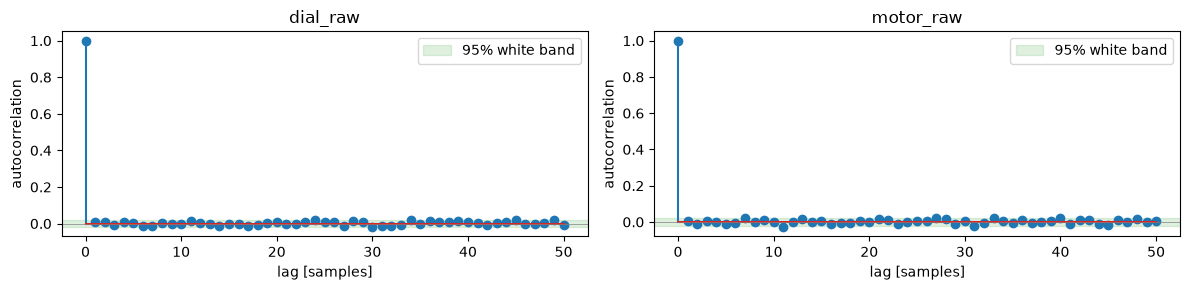

In [108]:
fig, axes = plt.subplots(1, len(signals), figsize=(6.0 * len(signals), 3.0))
for ax, (name, (segs, r)) in zip(np.atleast_1d(axes), analysis.items()):
    rr = r - r.mean()
    ac = np.correlate(rr, rr, "full")[len(rr) - 1:] / (rr.var() * len(rr))
    lags = np.arange(0, 51)
    ax.stem(lags, ac[:51])
    conf = 1.96 / np.sqrt(len(rr))
    ax.axhspan(-conf, conf, color="tab:green", alpha=0.15, label="95% white band")
    ax.axhline(0, color="0.5", lw=0.5)
    ax.set_title(name)
    ax.set_xlabel("lag [samples]")
    ax.set_ylabel("autocorrelation")
    ax.legend()
    stats[name]["ac1"] = float(ac[1])
fig.tight_layout()

for name, s in stats.items():
    print(f"{name}: autocorr lag-1 = {s['ac1']:+.3f}")

## Model coefficients

The model adds Gaussian noise in the **angle domain** and then quantizes to
14 bits; quantization itself contributes variance 1/12 LSB^2, so the
angle-domain sigma is deconvolved from the measured (already-quantized)
sigma. Each encoder instance gets its own sigma and its own seed
(decorrelated dither).

In [109]:
print("=" * 66)
print("AS5048 encoder noise - per-instance model coefficients")
print("=" * 66)
for name, (segs, r) in analysis.items():
    sigma = stats[name]["sigma"]
    sigma_angle = float(np.sqrt(max(sigma**2 - 1.0 / 12.0, 0.0)))
    stats[name]["sigma_angle"] = sigma_angle
    print(f"{name}:")
    print(f"  measured pooled sigma : {sigma:.3f} LSB   ({sigma * LSB_TO_MDEG:.1f} mdeg)")
    print(f"  angle-domain sigma    : {sigma_angle:.3f} LSB   (quantization deconvolved)")
    print(f"  distribution          : Gaussian (MAD agreement), WHITE (autocorr ~ 0)")
    print(f"  recommended model     : .with_noise(sigma_lsb = {sigma_angle:.2f}, seed)")
print("draw site               : per SPI transfer (each poll sees a fresh sample)")
print("seeds                   : distinct per instance (decorrelated)")
print("=" * 66)

AS5048 encoder noise - per-instance model coefficients
dial_raw:
  measured pooled sigma : 1.256 LSB   (27.6 mdeg)
  angle-domain sigma    : 1.222 LSB   (quantization deconvolved)
  distribution          : Gaussian (MAD agreement), WHITE (autocorr ~ 0)
  recommended model     : .with_noise(sigma_lsb = 1.22, seed)
motor_raw:
  measured pooled sigma : 1.544 LSB   (33.9 mdeg)
  angle-domain sigma    : 1.517 LSB   (quantization deconvolved)
  distribution          : Gaussian (MAD agreement), WHITE (autocorr ~ 0)
  recommended model     : .with_noise(sigma_lsb = 1.52, seed)
draw site               : per SPI transfer (each poll sees a fresh sample)
seeds                   : distinct per instance (decorrelated)


## Caveats

- Single board, bench temperature; both channels of this unit are
  characterized, and their sigmas agree within ~15% — per-instance values are
  used anyway since `with_noise` is per-instance.
- Telemetry sampled at 2 ms while the firmware reads at 1 ms; white noise is
  insensitive to that decimation.
- No drift was observable within dwells at this record length; if longer
  captures show 1/f drift, the model gains a slow term - measure first.